# New York City Airbnb — Exploratory Data Analysis

## Overview

This project performs an Exploratory Data Analysis (EDA) on the New York City Airbnb Open Data dataset.

The dataset contains information about Airbnb listings in New York City, including their location, room type, price, minimum nights, number of reviews, reviews per month, host listing count, and availability.

The goal of this analysis is to explore the dataset, identify patterns and relationships between variables, and generate meaningful insights about Airbnb listings in New York City.

## Dataset

**Source:** Kaggle — New York City Airbnb Open Data

The dataset contains information about Airbnb listings in New York City for 2019.

**Dataset:** [New York City Airbnb Open Data](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data)

## Analysis Objectives

The main objectives of this analysis are to:

- Understand the structure and characteristics of the dataset.
- Identify and handle missing or inconsistent data.
- Explore the distribution of Airbnb prices and other numerical variables.
- Analyze the distribution of listings across different neighborhoods.
- Compare different room types and their characteristics.
- Investigate relationships between price, location, reviews, availability, and other numerical variables.
- Identify important patterns and trends in the data.
- Summarize the key findings from the analysis.

## EDA Workflow

The analysis will follow these main steps:

1. Import the required libraries and load the dataset.
2. Understand the dataset structure and data types.
3. Check for missing values and duplicated records.
4. Clean and prepare the data.
5. Perform univariate analysis to understand individual variables.
6. Perform bivariate analysis to investigate relationships between variables.
7. Analyze correlations between numerical variables.
8. Extract key findings and summarize the main insights.

### 1. Importing Libraries

Before starting the analysis, we import the main Python libraries required for data manipulation, numerical operations, and data visualization.

* **NumPy**: Used for numerical operations and working with arrays.
* **Pandas**: Used for loading, cleaning, manipulating, and analyzing the dataset.
* **Matplotlib**: Used to create data visualizations and plots.
* **Seaborn**: Used to create statistical visualizations with a more informative and attractive style.


In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Loading the Dataset

Load the Airbnb dataset into a Pandas DataFrame for further exploration and analysis.


In [2]:
df = pd.read_csv('AB_NYC_2019.csv')

# 3. Understanding the Dataset

## Previewing the Dataset

Display the first few rows to get an initial overview of the dataset and its columns.


In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Dataset Dimensions

Check the number of rows and columns in the dataset.


In [99]:
df.shape

(48895, 16)

The dataset contains 48,895 listings and 16 features.

## Dataset Information

Inspect the dataset structure, data types, and number of non-null values in each column.


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

## Summary Statistics

Generate summary statistics for the numerical columns to understand their distributions and identify potential unusual values.


In [19]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,2018-10-04 01:47:23.910099,1.373221,7.143982,112.781327
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,2018-07-08 00:00:00,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,2019-05-19 00:00:00,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2019-06-23 00:00:00,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289


# 4. Data Cleaning

### Checking Missing Values

In [20]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

### Missing Values Findings

The dataset contains missing values in four columns:

* `name`: 16 missing values
* `host_name`: 21 missing values
* `last_review`: 10,052 missing values
* `reviews_per_month`: 10,052 missing values

The majority of the missing values are found in `last_review` and `reviews_per_month`. These missing values are related to listings that may not have received any reviews.

I will investigate these columns further before deciding how to handle the missing values.


### Checking Duplicates

I will check the dataset for duplicate rows.


df.duplicated()

### Checking Data Type

I will check the data type of `last_review` to determine whether it needs to be converted.


In [11]:
df['last_review'].dtype

<StringDtype(na_value=nan)>

### Converting Data Type

I will convert `last_review` to a datetime format for easier date analysis.


In [14]:
df['last_review'] = pd.to_datetime(df['last_review'])

In [16]:
df['last_review'].dtype

dtype('<M8[us]')

`last_review` is now stored in datetime format.


### Inspecting Missing Names

I will inspect the rows where the `name` value is missing.


In [22]:
df[df['name'].isnull()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
2854,1615764,NaN,6676776,Peter,Manhattan,Battery Park City,40.71239,-74.01620,Entire home/apt,400,1000,0,NaT,NaN,1,362
3703,2232600,NaN,11395220,Anna,Manhattan,East Village,40.73215,-73.98821,Entire home/apt,200,1,28,2015-06-08,0.45,1,341
5775,4209595,NaN,20700823,Jesse,Manhattan,Greenwich Village,40.73473,-73.99244,Entire home/apt,225,1,1,2015-01-01,0.02,1,0
5975,4370230,NaN,22686810,Michaël,Manhattan,Nolita,40.72046,-73.99550,Entire home/apt,215,7,5,2016-01-02,0.09,1,0
6269,4581788,NaN,21600904,Lucie,Brooklyn,Williamsburg,40.71370,-73.94378,Private room,150,1,0,NaT,NaN,1,0
6567,4756856,NaN,1832442,Carolina,Brooklyn,Bushwick,40.70046,-73.92825,Private room,70,1,0,NaT,NaN,1,0
6605,4774658,NaN,24625694,Josh,Manhattan,Washington Heights,40.85198,-73.93108,Private room,40,1,0,NaT,NaN,1,0
8841,6782407,NaN,31147528,Huei-Yin,Brooklyn,Williamsburg,40.71354,-73.93882,Private room,45,1,0,NaT,NaN,1,0
11963,9325951,NaN,33377685,Jonathan,Manhattan,Hell's Kitchen,40.76436,-73.98573,Entire home/apt,190,4,1,2016-01-05,0.02,1,0
12824,9787590,NaN,50448556,Miguel,Manhattan,Harlem,40.80316,-73.95189,Entire home/apt,300,5,0,NaT,NaN,5,0


### Inspecting Missing Host Names

I will inspect the rows where `host_name` is missing.


In [24]:
df[df['host_name'].isnull()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
360,100184,Bienvenue,526653,NaN,Queens,Queens Village,40.72413,-73.76133,Private room,50,1,43,2019-07-08,0.45,1,88
2700,1449546,Cozy Studio in Flatbush,7779204,NaN,Brooklyn,Flatbush,40.64965,-73.96154,Entire home/apt,100,30,49,2017-01-02,0.69,1,342
5745,4183989,SPRING in the City!! Zen-Style Tranquil Bedroom,919218,NaN,Manhattan,Harlem,40.80606,-73.95061,Private room,86,3,34,2019-05-23,1.00,1,359
6075,4446862,Charming Room in Prospect Heights!,23077718,NaN,Brooklyn,Crown Heights,40.67512,-73.96146,Private room,50,1,0,NaT,NaN,1,0
6582,4763327,"Luxurious, best location, spa inc'l",24576978,NaN,Brooklyn,Greenpoint,40.72035,-73.95355,Entire home/apt,195,1,1,2015-10-20,0.02,1,0
8163,6292866,Modern Quiet Gem Near All,32722063,NaN,Brooklyn,East Flatbush,40.65263,-73.93215,Entire home/apt,85,2,182,2019-06-19,3.59,2,318
8257,6360224,"Sunny, Private room in Bushwick",33134899,NaN,Brooklyn,Bushwick,40.70146,-73.92792,Private room,37,1,1,2015-07-01,0.02,1,0
8852,6786181,R&S Modern Spacious Hideaway,32722063,NaN,Brooklyn,East Flatbush,40.64345,-73.93643,Entire home/apt,100,2,157,2019-06-19,3.18,2,342
9138,6992973,1 Bedroom in Prime Williamsburg,5162530,NaN,Brooklyn,Williamsburg,40.71838,-73.95630,Entire home/apt,145,1,0,NaT,NaN,1,0
9817,7556587,Sunny Room in Harlem,39608626,NaN,Manhattan,Harlem,40.82929,-73.94182,Private room,28,1,1,2015-08-01,0.02,1,0


### Handling Missing Values

I will replace the missing values in `name` and `host_name` with `"Unknown"`.


In [25]:
df['name']=df['name'].fillna('Unknown')
df['host_name']=df['host_name'].fillna('UnKnown')

### Rechecking Missing Values

I will check the missing values again after handling `name` and `host_name`.


In [26]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

### Investigating Missing Reviews

I will check whether the missing review data is related to listings with no reviews.


In [29]:
df[df['number_of_reviews'] == 0][['number_of_reviews', 'last_review', 'reviews_per_month']].isnull().sum()

number_of_reviews        0
last_review          10052
reviews_per_month    10052
dtype: int64

### Handling Review Data

I will replace missing values in `reviews_per_month` with `0`.


In [30]:
df['reviews_per_month']=df['reviews_per_month'].fillna(0)

### Rechecking Missing Values

I will check the missing values again after cleaning the review data.


df.isnull().sum()

### Handling Last Review

I will replace missing values in `last_review` with `"NaN"`.


In [32]:
df['last_review']=df['last_review'].fillna('NaN')

In [33]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

### Missing Values Conclusion

The missing values in `last_review` represent listings with no reviews, so I will keep them as missing values.


### Checking Price Values

I will examine the summary statistics of `price` to identify unusual or invalid values.


In [36]:
df['price'].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

### Checking Zero Prices

I will check how many listings have a price of zero.


In [37]:
(df['price']==0).sum()

np.int64(11)

### Inspecting Zero Prices

I will inspect the listings with a price of zero before handling them.


In [38]:
df[df['price'] == 0][['name', 'room_type', 'neighbourhood_group', 'price']]

,name,room_type,neighbourhood_group,price
23161,"Huge Brooklyn Brownstone Living, Close to it all.",Private room,Brooklyn,0
25433,★Hostel Style Room | Ideal Traveling Buddies★,Private room,Bronx,0
25634,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",Private room,Brooklyn,0
25753,"Sunny, Quiet Room in Greenpoint",Private room,Brooklyn,0
25778,Modern apartment in the heart of Williamsburg,Entire home/apt,Brooklyn,0
25794,Spacious comfortable master bedroom with nice ...,Private room,Brooklyn,0
25795,Contemporary bedroom in brownstone with nice view,Private room,Brooklyn,0
25796,Cozy yet spacious private brownstone bedroom,Private room,Brooklyn,0
26259,the best you can find,Entire home/apt,Manhattan,0
26841,Coliving in Brooklyn! Modern design / Shared room,Shared room,Brooklyn,0


### Inspecting High Prices

I will inspect the listings with the highest price to check whether they are unusual.


In [39]:
df[df['price'] == 10000][['name', 'room_type', 'neighbourhood_group', 'price']]

,name,room_type,neighbourhood_group,price
9151,Furnished room in Astoria apartment,Private room,Queens,10000
17692,Luxury 1 bedroom apt. -stunning Manhattan views,Entire home/apt,Brooklyn,10000
29238,1-BR Lincoln Center,Entire home/apt,Manhattan,10000


### Calculating IQR

I will calculate Q1 and Q3 to identify potential outliers in `price`.


In [40]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

print("Q1:", Q1)
print("Q3:", Q3)

Q1: 69.0
Q3: 175.0


In [41]:
IQR = Q3 - Q1
print("IQR:", IQR)

IQR: 106.0


In [42]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower bound:", lower)
print("Upper bound:", upper)

Lower bound: -90.0
Upper bound: 334.0


In [43]:
(df['price'] > upper).sum()

np.int64(2972)

In [44]:
df[df['price'] == 0].shape

(11, 16)

### Zero Price Finding

There are 11 listings with a price of 0, which may represent invalid price values.


### Handling Zero Prices

I will replace zero prices with missing values because a price of 0 is not valid for this analysis.


In [45]:
df['price'] = df['price'].replace(0, np.nan)

In [46]:
df['price'].isnull().sum()

np.int64(11)

## 5. Exploratory Data Analysis

In this section, I will explore the dataset to identify patterns, trends, and relationships between the variables.

I will analyze important features such as price, room type, neighborhood, reviews, and availability.


### Price Distribution

I will visualize the distribution of Airbnb prices to identify common price ranges and unusual values.


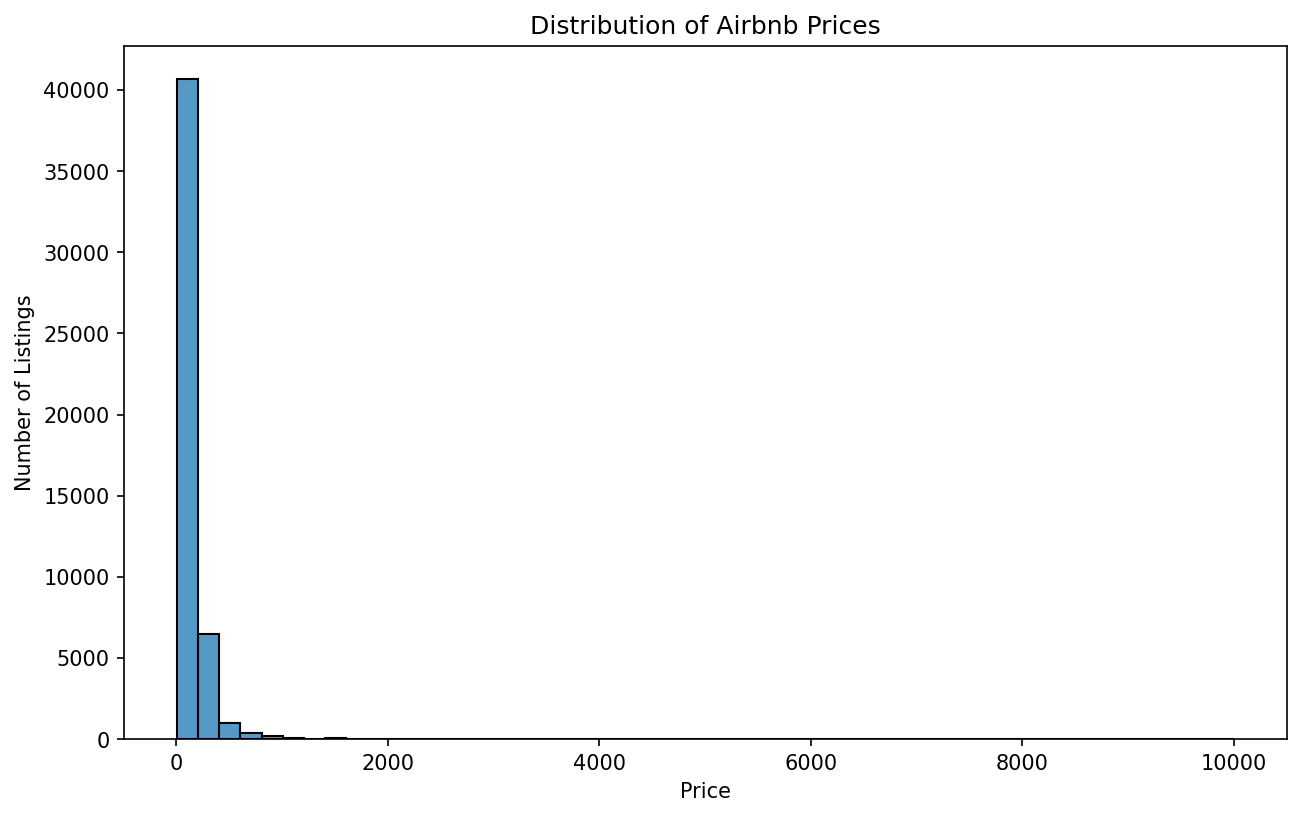

In [48]:
plt.figure(figsize=(10,6),dpi=150)
sns.histplot(df['price'],bins=50)
plt.title('Distribution of Airbnb Prices')
plt.xlabel('Price')
plt.ylabel('Number of Listings')
plt.show()

### Price Distribution Finding

The price distribution is heavily right-skewed, with most listings having relatively low prices and a small number of very expensive listings.

This indicates the presence of high-price outliers and suggests that the median may better represent the typical listing price than the mean.


### Neighbourhood Group Analysis

I will explore the distribution of Airbnb listings across different neighbourhood groups.


In [49]:
df['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

### Neighbourhood Group Finding

Manhattan and Brooklyn have the highest number of listings, while Staten Island has the fewest.


### Visualizing Neighbourhood Groups

I will visualize the distribution of Airbnb listings across neighbourhood groups.


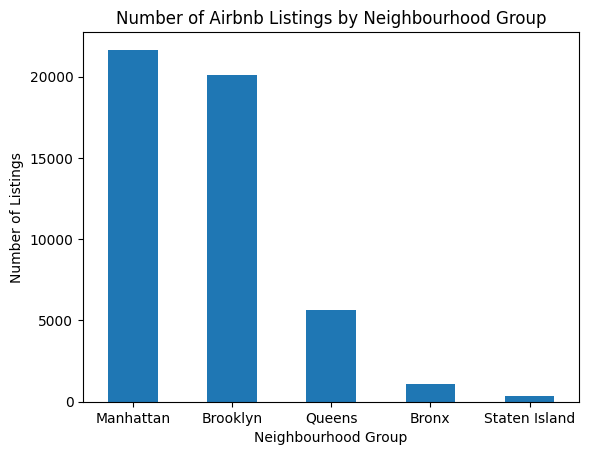

In [50]:
df['neighbourhood_group'].value_counts().plot(kind='bar')

plt.title('Number of Airbnb Listings by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')
plt.xticks(rotation=0)
plt.show()

### Neighbourhood Group Finding

Manhattan and Brooklyn have the highest number of Airbnb listings, while Bronx and Staten Island have the fewest.


### Room Type Analysis

I will explore the distribution of Airbnb listings across different room types.


In [51]:
df['room_type'].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

### Room Type Finding

Entire home/apt is the most common room type, followed by Private room, while Shared room is much less common.


### Visualizing Room Types

I will visualize the distribution of Airbnb listings by room type.


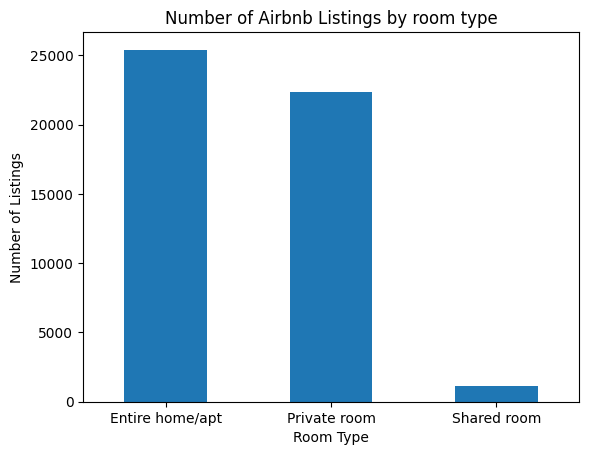

In [52]:
df['room_type'].value_counts().plot(kind='bar')
plt.title('Number of Airbnb Listings by room type')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')
plt.xticks(rotation=0)
plt.show()

### Room Type Finding

Entire home/apt and Private room dominate the dataset, while Shared room represents a very small proportion of listings.


### Minimum Nights Analysis

I will examine the distribution of minimum nights required for Airbnb bookings.


In [53]:
df['minimum_nights'].describe()

count    48895.000000
mean         7.029962
std         20.510550
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64

### Visualizing Minimum Nights

I will visualize the distribution of minimum nights required for Airbnb listings.


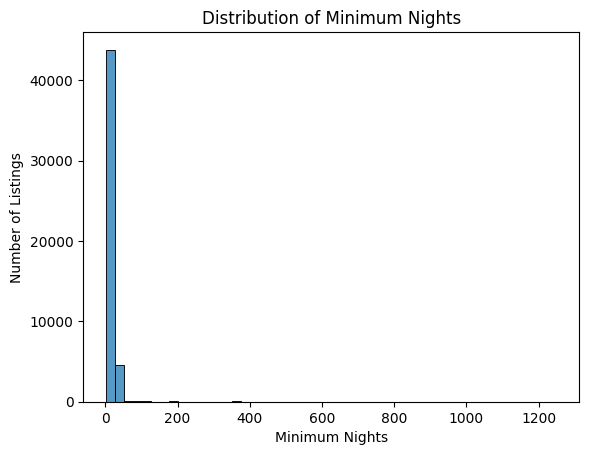

In [56]:
sns.histplot(df['minimum_nights'], bins=50)

plt.title('Distribution of Minimum Nights')
plt.xlabel('Minimum Nights')
plt.ylabel('Number of Listings')
plt.show()

### Minimum Nights Finding

The distribution is extremely right-skewed, with most listings requiring a small number of minimum nights.

A small number of listings have very high minimum-night requirements, indicating potential outliers.


### Number of Reviews Analysis

I will examine the summary statistics of `number_of_reviews` to understand the distribution of reviews across listings.


In [57]:
df['number_of_reviews'].describe()

count    48895.000000
mean        23.274466
std         44.550582
min          0.000000
25%          1.000000
50%          5.000000
75%         24.000000
max        629.000000
Name: number_of_reviews, dtype: float64

### Visualizing Number of Reviews

I will visualize the distribution of reviews across Airbnb listings.


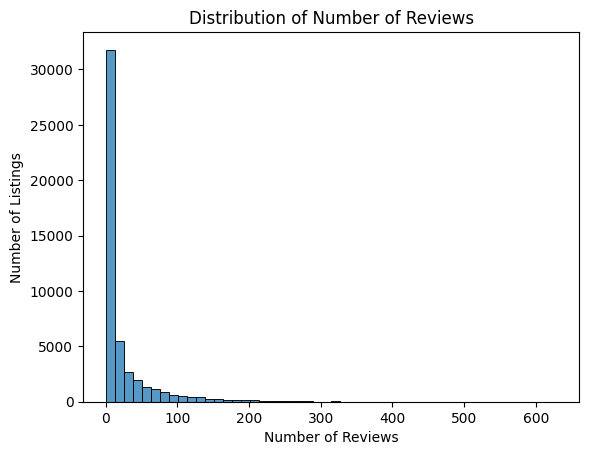

In [58]:
sns.histplot(df['number_of_reviews'], bins=50)

plt.title('Distribution of Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Listings')
plt.show()

### Number of Reviews Finding

The distribution is strongly right-skewed, with most listings having few or no reviews.

Only a small number of listings have a high number of reviews, creating a long tail.


### Average Price by Room Type

I will compare the average Airbnb price across different room types.


In [59]:
df.groupby('room_type')['price'].mean()

room_type
Entire home/apt    211.810918
Private room        89.809131
Shared room         70.248705
Name: price, dtype: float64

### Median Price by Room Type

I will compare the median Airbnb price across different room types.


In [60]:
df.groupby('room_type')['price'].median()

room_type
Entire home/apt    160.0
Private room        70.0
Shared room         45.0
Name: price, dtype: float64

### Visualizing Median Price by Room Type

I will visualize the median Airbnb price for each room type.


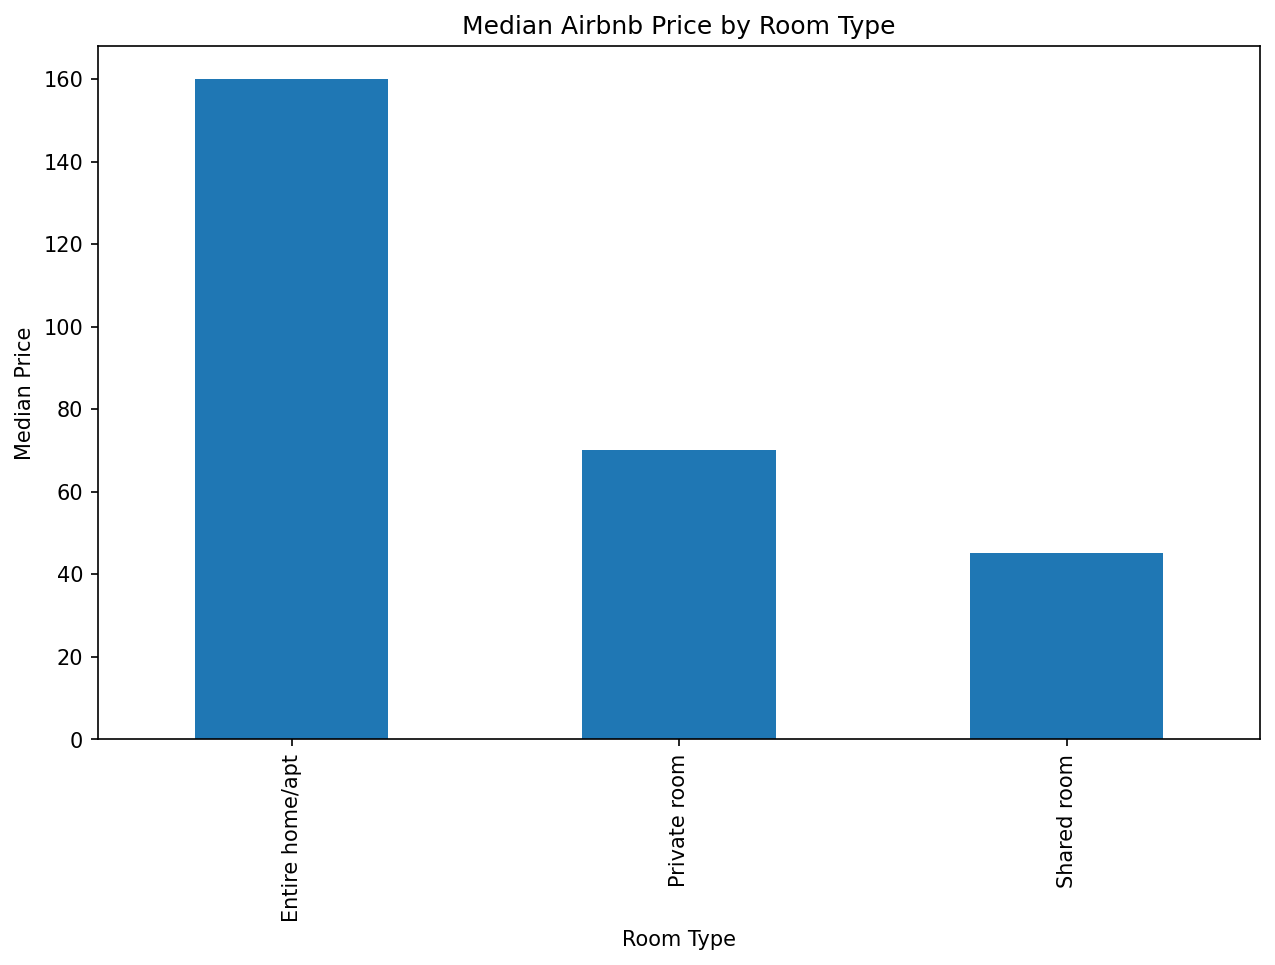

In [66]:
plt.figure(figsize=(10,6),dpi=150)
df.groupby('room_type')['price'].median().plot(kind='bar')
plt.title('Median Airbnb Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Median Price')
plt.show()

### Median Price Finding

Entire home/apt has the highest median price, followed by Private room and Shared room.

This shows a clear relationship between room type and typical listing price.


### Median Price by Neighbourhood Group

I will compare the median Airbnb price across different neighbourhood groups.


In [62]:
df.groupby('neighbourhood_group')['price'].median()

neighbourhood_group
Bronx             65.0
Brooklyn          90.0
Manhattan        150.0
Queens            75.0
Staten Island     75.0
Name: price, dtype: float64

### Visualizing Median Price by Neighbourhood Group

I will visualize the median Airbnb price across neighbourhood groups.


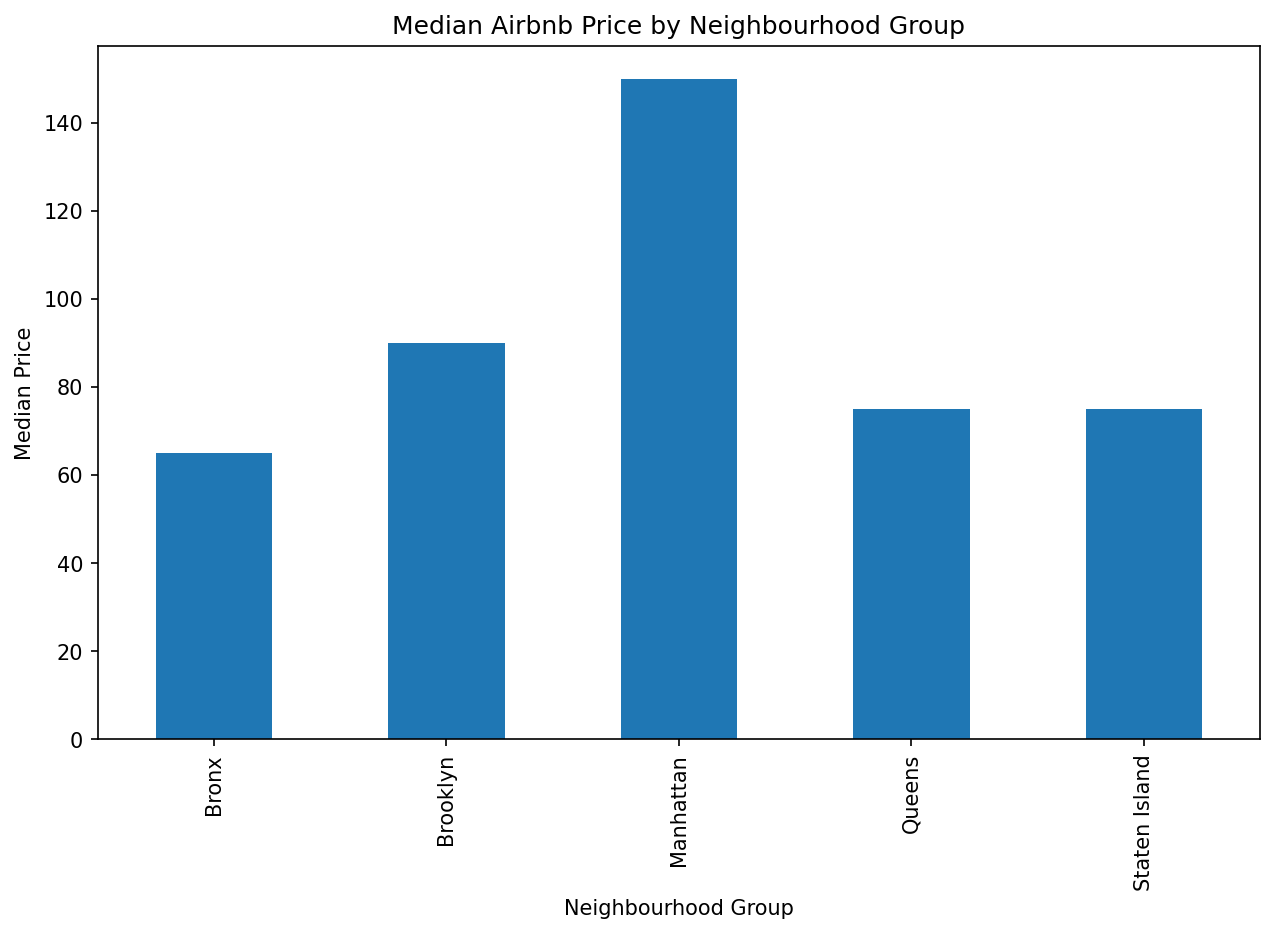

In [67]:
plt.figure(figsize=(10,6),dpi=150)
df.groupby('neighbourhood_group')['price'].median().plot(kind='bar')
plt.title('Median Airbnb Price by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Median Price')
plt.show()

### Median Price Finding

Manhattan has the highest median price, followed by Brooklyn, while the Bronx has the lowest.

This shows a clear relationship between neighbourhood group and typical listing price.


### Median Price by Number of Reviews

I will examine how the median Airbnb price varies with the number of reviews.


In [68]:
df.groupby('number_of_reviews')['price'].median()

number_of_reviews
0      120.0
1      100.0
2      100.0
3      110.0
4      110.0
       ...  
576     47.0
594     49.0
597     49.0
607     49.0
629     47.0
Name: price, Length: 394, dtype: float64

### Reviews vs Median Price

I will explore the relationship between the number of reviews and the median listing price.


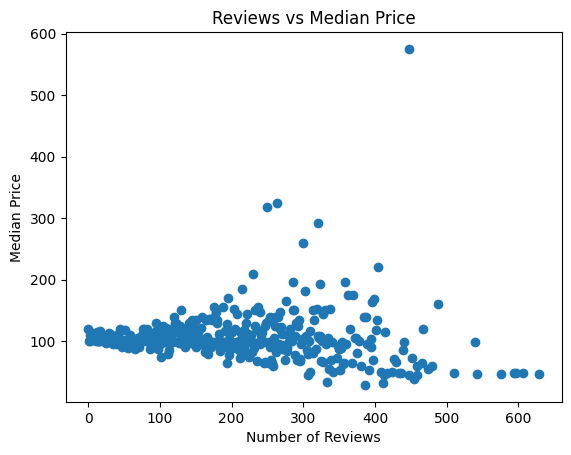

In [70]:
review_price = df.groupby('number_of_reviews')['price'].median()

plt.scatter(review_price.index, review_price.values)

plt.title('Reviews vs Median Price')
plt.xlabel('Number of Reviews')
plt.ylabel('Median Price')
plt.show()

### Reviews vs Median Price Finding

There is no strong relationship between the number of reviews and median price.

Most listings have relatively few reviews, while highly reviewed listings tend to have lower prices.


### Availability vs Median Price

I will examine how the median Airbnb price varies with the number of available days per year.


In [73]:
df.groupby('availability_365')['price'].median().head(20)

availability_365
0     100.0
1     108.0
2     114.0
3     115.0
4     120.0
5     110.0
6     100.0
7     110.0
8     110.0
9     125.0
10    120.0
11    115.0
12    110.5
13    107.5
14    120.0
15    110.0
16    110.0
17    118.0
18    102.0
19    105.0
Name: price, dtype: float64

### Availability vs Median Price

I will explore the relationship between listing availability and median price.


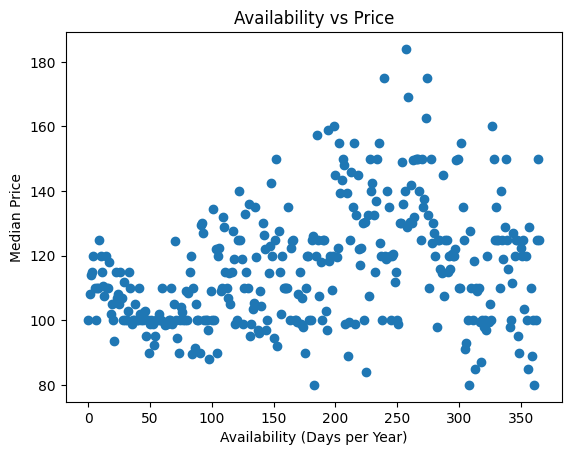

In [75]:
availability_price = df.groupby('availability_365')['price'].median()

plt.scatter(availability_price.index, availability_price.values)

plt.title('Availability vs Price')
plt.xlabel('Availability (Days per Year)')
plt.ylabel('Median Price')
plt.show()

### Availability vs Median Price Finding

There is a weak positive relationship between availability and median price.

Prices become slightly higher as availability increases, but the relationship is scattered and not strong.


### Median Price by Neighbourhood and Room Type

I will compare the median price across different neighbourhood groups and room types.


In [86]:
room_neighborhood_price = df.groupby(['neighbourhood_group', 'room_type'])['price'].median()

room_neighborhood_price

neighbourhood_group  room_type      
Bronx                Entire home/apt    100.0
                     Private room        54.0
                     Shared room         40.0
Brooklyn             Entire home/apt    145.0
                     Private room        65.0
                     Shared room         36.0
Manhattan            Entire home/apt    191.0
                     Private room        90.0
                     Shared room         69.0
Queens               Entire home/apt    120.0
                     Private room        60.0
                     Shared room         37.0
Staten Island        Entire home/apt    100.0
                     Private room        50.0
                     Shared room         30.0
Name: price, dtype: float64

### Median Price by Neighbourhood and Room Type

I will compare median prices across neighbourhood groups for each room type.


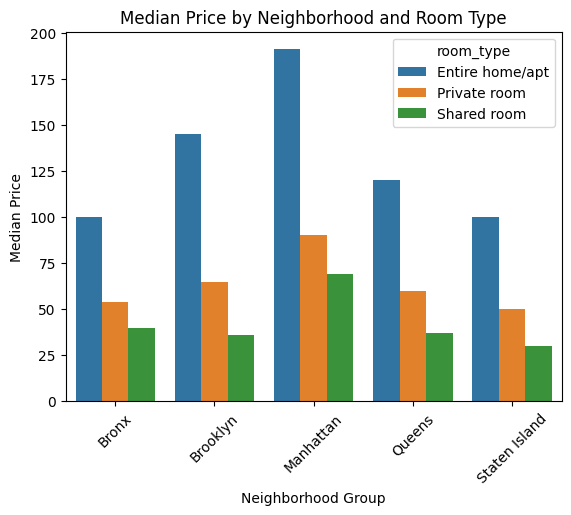

In [89]:
sns.barplot(data=room_neighborhood_price,x='neighbourhood_group',y='price',hue='room_type')
plt.title('Median Price by Neighborhood and Room Type')
plt.xlabel('Neighborhood Group')
plt.ylabel('Median Price')
plt.xticks(rotation=45)
plt.show()

### Median Price Finding

Entire home/apt has the highest median price across all neighbourhood groups, while Shared room is the cheapest.

Manhattan has the highest prices overall, showing that room type and neighbourhood group both influence listing prices.


## 6. Correlation Analysis

To understand the linear relationships between the numerical variables, I calculated a correlation matrix and visualized it using a heatmap.

The correlation coefficient ranges from -1 to +1:

* Values close to +1 indicate a strong positive linear relationship.
* Values close to -1 indicate a strong negative linear relationship.
* Values close to 0 indicate little or no linear relationship.

The correlation matrix helps identify relationships between variables and can highlight potential patterns for further analysis.


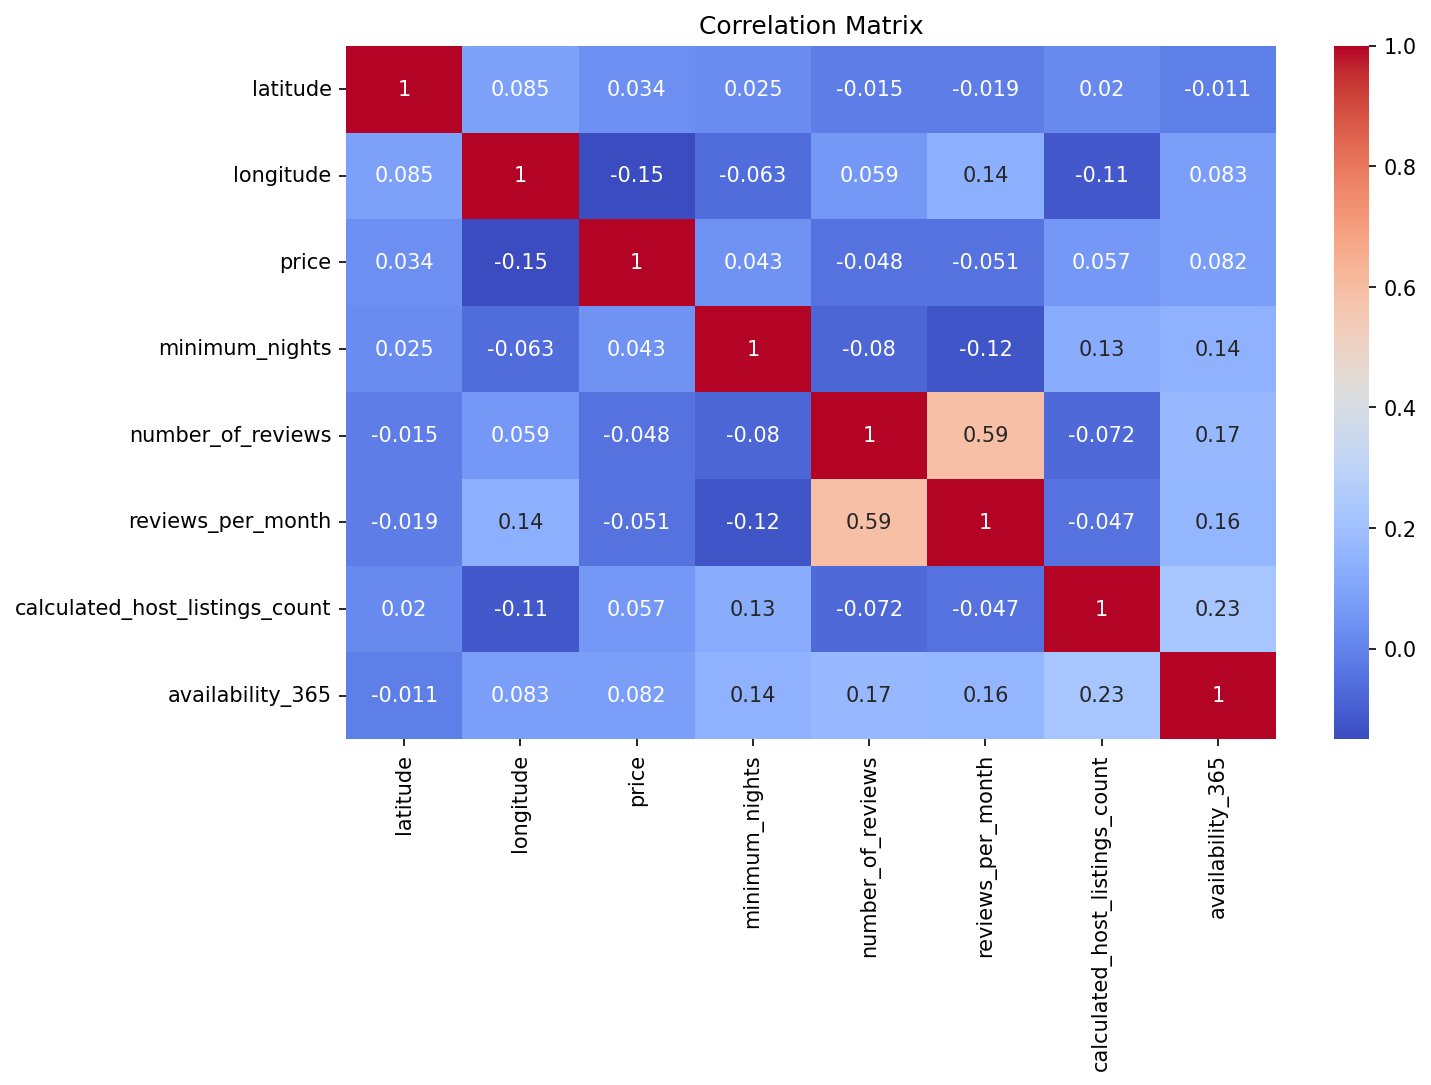

In [98]:
plt.figure(figsize=(10,6),dpi=150)
corr = df[['latitude',
           'longitude',
           'price',
           'minimum_nights',
           'number_of_reviews',
           'reviews_per_month',
           'calculated_host_listings_count',
           'availability_365']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

### Key Insights

- `number_of_reviews` and `reviews_per_month` have the strongest correlation in the dataset, with a correlation coefficient of **0.59**. This indicates a moderate positive linear relationship. Listings that receive more reviews overall tend to also have more reviews per month.

- `calculated_host_listings_count` and `availability_365` have a weak positive correlation of **0.23**. This suggests that hosts with more listings may have slightly higher availability across the year, although the relationship is relatively weak.

- `longitude` and `price` have a weak negative correlation of **-0.15**, suggesting that longitude alone has little linear relationship with listing price.

- `minimum_nights` has generally weak correlations with the other variables. For example, its correlation with `reviews_per_month` is **-0.12**, indicating only a very weak negative relationship.

- `latitude` has correlations very close to zero with most variables, suggesting that latitude alone does not have a meaningful linear relationship with these numerical features.

- Overall, most numerical variables show weak linear correlations with each other. This suggests that there are no widespread strong linear relationships among the features, except for the relationship between `number_of_reviews` and `reviews_per_month`.

## 7. Overall Key Findings

* **Manhattan and Brooklyn** have the highest number of Airbnb listings.
* **Entire home/apt** is the most common room type and has the highest median price.
* **Manhattan** has the highest median listing price among neighbourhood groups.
* **Price, minimum nights, and number of reviews** have highly skewed distributions with potential outliers.
* **Room type and neighbourhood group** show clear relationships with listing prices.
* Most numerical variables have **weak linear correlations**, with `number_of_reviews` and `reviews_per_month` showing the strongest correlation.


## 8. Conclusion

The EDA provided a clear overview of Airbnb listings in New York City.

The analysis highlighted important patterns in **pricing, room types, neighbourhoods, reviews, and availability**, providing a foundation for further analysis and modeling.
